In [15]:
import numpy as np
from tqdm import tqdm

In [21]:
waveform_list_ = []
for i in tqdm(range(10)):
    print(len(np.load('waveform_after_pattern_cut/waveform_{}.npz'.format(i))['pile_up_waveform']))
    waveform_list_.append(np.load('waveform_after_pattern_cut/waveform_{}.npz'.format(i))['pile_up_waveform'])

waveform_array = np.concatenate(waveform_list_)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 429.38it/s]

7
6
10
7
6
7
8
10
7
4


In [30]:
test_de_data = waveform_array.reshape(-1, 1, 3500)
test_de_labels = np.zeros(len(test_de_data))
test_de_pe = np.sum(np.sum(test_de_data,axis = 1),axis = 1)

test_data = test_de_data.reshape(-1, 1, 3500)
test_labels = np.zeros(len(test_data))
test_pe = np.sum(np.sum(test_data,axis = 1),axis = 1)

In [31]:
import torch
import torch.nn as nn
import pickle
from PIL import Image
import h5py

#神经网络的结构，得跑一下才能把后面有些定义的变量弄进去，不耗时间
class WaveformClassifier(nn.Module):
    def __init__(self):
        super(WaveformClassifier, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.global_pool = nn.AdaptiveAvgPool1d(1)  # 使用全局平均池化层
        self.fc = nn.Sequential(
            nn.Linear(128, 64),  # 修改全连接层的输入维度
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 2)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.global_pool(x).squeeze(2)
        x = self.fc(x)
        return x
    

In [32]:
#把测试集的名字换成我们需要的，test_filename = 'test3.pkl'，这个。然后用已经做好的模型model.load_state_dict(torch.load('waveform_classifier.pth'))得到一个分数
#这个分数存在h5_filename = 'scores3.h5'这里面

# # 加载测试集数据和标签
# test_filename = 'test3.pkl'
# 长度为3500的波形？
# train_loss_values = []  # 保存训练损失值的列表
# test_loss_values = []   # 保存测试损失值的列表

# with open(test_filename, 'rb') as f:
#     test_data, test_labels, test_pe = pickle.load(f)



# # 转换数据通道数为1并调整大小
# test_data = test_data.reshape(-1, 1, 3500)

# 将测试集数据和标签转换为PyTorch张量
test_data = torch.from_numpy(test_data).float()
test_labels = torch.from_numpy(test_labels).long()

# 创建测试集数据集和数据加载器
test_dataset = torch.utils.data.TensorDataset(test_data, test_labels)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

# 加载模型
model = WaveformClassifier()
model.load_state_dict(torch.load('sim_config/waveform_classifier.pth'))


# 测试模式
model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0
test_confusion_matrix = torch.zeros(2, 2)
criterion = nn.CrossEntropyLoss()

num_epochs = 2
with torch.no_grad():
    for batch_data, batch_labels in test_dataloader:
        outputs = model(batch_data)
        loss = criterion(outputs, batch_labels)
        test_loss += loss.item() * batch_data.size(0)

        # 计算测试集准确率和混淆矩阵
        _, predicted = torch.max(outputs, 1)
        test_total += batch_labels.size(0)
        test_correct += (predicted == batch_labels).sum().item()

        for i in range(len(predicted)):
            test_confusion_matrix[batch_labels[i]][predicted[i]] += 1

# 计算平均测试集损失函数和准确率
test_loss /= len(test_dataset)
test_accuracy = test_correct / test_total

# 计算标签0判断为标签1和标签1判断为标签0的概率
test_false_positive = test_confusion_matrix[0][1] / test_confusion_matrix[0].sum()
test_false_negative = test_confusion_matrix[1][0] / test_confusion_matrix[1].sum()

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
print(f"Test False Positive Rate: {test_false_positive:.4f}, Test False Negative Rate: {test_false_negative:.4f}")


# 在测试集上进行评估
model.eval()
test_confusion_matrix = torch.zeros(2, 2)

# 在测试集上计算预测分数
with torch.no_grad():
    model.eval()
    outputs = model(test_data)
    scores = torch.softmax(outputs, dim=1)

# 绘制预测分数的分布
scores_label_0 = scores[test_labels == 0]
scores_label_1 = scores[test_labels == 1]


Test Loss: 0.5972, Test Accuracy: 0.6806
Test False Positive Rate: 0.3194, Test False Negative Rate: nan


/home/cchang/.conda/envs/geant4/lib/python3.8/site-packages/numpy/lib/histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


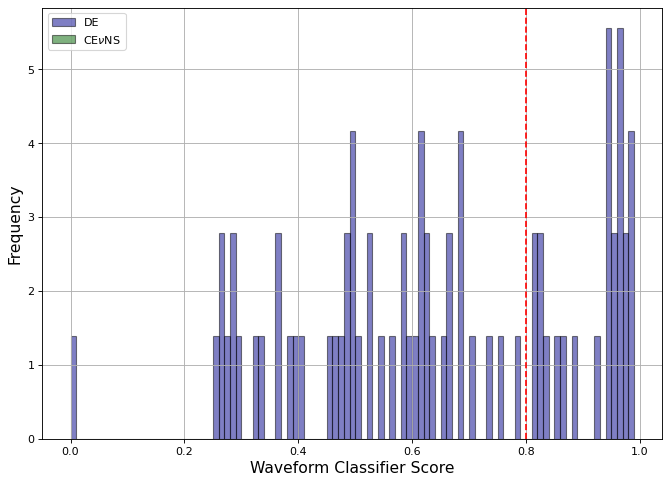

In [33]:
import matplotlib.pyplot as plt
# 创建一个新的图形并设置大小
fig= plt.figure(figsize=(10, 7),dpi = 80)
plt.hist(scores_label_0[:, 0].numpy(), bins=np.arange(0,1,0.01), edgecolor='black', alpha=0.5, label='DE', density=True, color='darkblue')
plt.hist(scores_label_1[:, 0].numpy(), bins=np.arange(0,1,0.01), edgecolor='black', alpha=0.5, label=r"CE$\nu$NS", density=True, color='darkgreen')

plt.xlabel('Waveform Classifier Score', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
#plt.title('Distribution of Prediction Scores')
plt.legend()
# plt.savefig('defen.svg', transparent=True, dpi=400, bbox_inches='tight')
plt.axvline(x=0.8, color='red', linestyle='dashed')
plt.grid()
plt.show()


# h5_filename = 'scores3.h5'
# h5_file = h5py.File(h5_filename, 'w')

# # 将得分存储为名为'scores'的数据集
# h5_file.create_dataset('scores', data=scores.numpy())

# # 关闭HDF5文件
# h5_file.close()
